In [6]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import sys
import json
import math
import random
from pathlib import Path

import numpy as np
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

sys.path.append("/mnt/data")
from losses import (
    masked_mse, masked_rmse, masked_mae, masked_mape, masked_r2,
    masked_rmse_per_t, masked_mae_per_t,
)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.cmap"] = "coolwarm"

In [7]:
class FactorizedSTBlock(nn.Module):
    def __init__(self, d_model, nhead, mlp_ratio=4.0, dropout=0.0, attn_dropout=0.0):
        super().__init__()
        self.ln_s = nn.LayerNorm(d_model)
        self.attn_s = nn.MultiheadAttention(
            d_model, nhead, dropout=attn_dropout, batch_first=True
        )

        self.ln_t = nn.LayerNorm(d_model)
        self.attn_t = nn.MultiheadAttention(
            d_model, nhead, dropout=attn_dropout, batch_first=True
        )

        self.ln_m = nn.LayerNorm(d_model)
        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(
        self,
        x,
        return_attn: bool = False,
        average_attn_weights: bool = False,
    ):
        B, T, N, D = x.shape
        aux = {}

        xs = self.ln_s(x).reshape(B * T, N, D)
        if return_attn:
            ys, attn_s = self.attn_s(
                xs, xs, xs,
                need_weights=True,
                average_attn_weights=average_attn_weights,
            )
        else:
            ys, _ = self.attn_s(xs, xs, xs, need_weights=False)

        x = x + ys.reshape(B, T, N, D)

        xt = self.ln_t(x).permute(0, 2, 1, 3).reshape(B * N, T, D)
        if return_attn:
            yt, attn_t = self.attn_t(
                xt, xt, xt,
                need_weights=True,
                average_attn_weights=average_attn_weights,
            )
        else:
            yt, _ = self.attn_t(xt, xt, xt, need_weights=False)

        x = x + yt.reshape(B, N, T, D).permute(0, 2, 1, 3)
        x = x + self.mlp(self.ln_m(x))

        if return_attn:
            if average_attn_weights:
                attn_s = attn_s.reshape(B, T, N, N)
            else:
                Hh = attn_s.shape[1]
                attn_s = attn_s.reshape(B, T, Hh, N, N)

            if average_attn_weights:
                attn_t = attn_t.reshape(B, N, T, T)
            else:
                Hh = attn_t.shape[1]
                attn_t = attn_t.reshape(B, N, Hh, T, T)

            aux["spatial_attn"] = attn_s.detach()
            aux["temporal_attn"] = attn_t.detach()
            return x, aux

        return x


class MSFormerV3(nn.Module):
    def __init__(
        self,
        image_size=32,
        in_chans=1,
        tin=14,
        tout=7,
        d_model=128,
        depth=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.0,
        attn_dropout=0.0,
        spatial_scales=(2, 4, 8, 16, 32),
        fusion="sum",
        use_pad=True,
        use_pos_emb=False,
        time_pool="last",
    ):
        super().__init__()
        self.image_size = int(image_size)
        self.in_chans = int(in_chans)
        self.tin = int(tin)
        self.tout = int(tout)
        self.d_model = int(d_model)
        self.depth = int(depth)

        self.scales = tuple(int(s) for s in spatial_scales)
        assert len(self.scales) >= 1
        self.fusion = fusion
        assert self.fusion in ["sum", "gated", "gated2"]
        self.use_pad = bool(use_pad)
        self.use_pos_emb = bool(use_pos_emb)
        self.time_pool = str(time_pool)
        assert self.time_pool in ["mean", "last"]

        self.smoother = nn.Sequential(
            nn.Conv2d(self.in_chans, self.in_chans, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(self.in_chans, self.in_chans, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(self.in_chans, self.in_chans, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(self.in_chans, self.in_chans, kernel_size=3, padding=1),
        )

        self.tokenizers = nn.ModuleDict()
        for s in self.scales:
            self.tokenizers[str(s)] = nn.Conv2d(
                self.in_chans, self.d_model, kernel_size=s, stride=s, bias=True
            )

        self.time_emb = nn.Embedding(self.tin, self.d_model)
        self.scale_emb = nn.Embedding(len(self.scales), self.d_model)

        self.pos_emb = nn.ModuleDict()
        if self.use_pos_emb:
            for s in self.scales:
                gs = self.image_size // s
                Ns = gs * gs
                self.pos_emb[str(s)] = nn.Embedding(Ns, self.d_model)

        self.blocks = nn.ModuleList([
            FactorizedSTBlock(self.d_model, num_heads, mlp_ratio, dropout, attn_dropout)
            for _ in range(depth)
        ])
        self.ln_f = nn.LayerNorm(self.d_model)

        self.future_heads = nn.ModuleDict()
        self.token_to_patch = nn.ModuleDict()
        for s in self.scales:
            self.future_heads[str(s)] = nn.Linear(self.d_model, self.tout * self.d_model)
            self.token_to_patch[str(s)] = nn.Linear(self.d_model, self.in_chans * s * s)

        if self.fusion in ["gated", "gated2"]:
            self.gate = nn.Sequential(
                nn.Linear(self.d_model * len(self.scales), self.d_model),
                nn.GELU(),
                nn.Linear(self.d_model, len(self.scales)),
            )
        else:
            self.gate = None

    def _pad_to_multiple(self, x, multiple: int):
        h, w = x.shape[-2], x.shape[-1]
        pad_h = (multiple - (h % multiple)) % multiple
        pad_w = (multiple - (w % multiple)) % multiple
        if pad_h == 0 and pad_w == 0:
            return x, (0, 0)
        x = F.pad(x, (0, pad_w, 0, pad_h), mode="replicate")
        return x, (pad_h, pad_w)

    def _tokenize_one_scale(self, x_btchw, s: int):
        tok = self.tokenizers[str(s)](x_btchw)
        gh, gw = tok.shape[-2], tok.shape[-1]
        tok = tok.flatten(2).transpose(1, 2)
        return tok, gh, gw

    def _decode_scale(self, fut, s: int, gh: int, gw: int):
        B = fut.shape[0]
        patch_vec = self.token_to_patch[str(s)](fut)
        patch_vec = patch_vec.reshape(B, self.tout, gh, gw, self.in_chans, s, s)
        patch_vec = patch_vec.permute(0, 1, 4, 2, 5, 3, 6).contiguous()
        y = patch_vec.reshape(B, self.tout, self.in_chans, gh * s, gw * s)
        return y

    def _pool_scale_rep(self, tok):
        if self.time_pool == "last":
            rep = tok[:, -1].mean(dim=1)
        else:
            rep = tok.mean(dim=(1, 2))
        return rep

    def forward(
        self,
        x,
        return_interpret: bool = False,
        return_attn: bool = False,
        attn_layers=None,
        average_attn_weights: bool = True,
    ):
        B, Tin, C, H, W = x.shape
        assert C == self.in_chans
        assert Tin == self.tin, f"Tin mismatch: got {Tin}, expected {self.tin}"

        if attn_layers is None:
            attn_layers = []
        attn_layers = set([(self.depth + i) if i < 0 else i for i in attn_layers])

        interpret = {} if return_interpret else None

        xt = x.reshape(B * Tin, C, H, W)
        if self.use_pad:
            xt, (pad_h, pad_w) = self._pad_to_multiple(xt, max(self.scales))
        else:
            pad_h, pad_w = 0, 0

        scale_tokens = []
        scale_meta = []
        t_idx = torch.arange(Tin, device=x.device)

        for sid, s in enumerate(self.scales):
            tok_s, gh, gw = self._tokenize_one_scale(xt, s)
            Ns = gh * gw
            tok_s = tok_s.reshape(B, Tin, Ns, self.d_model)

            tok_s = tok_s + self.time_emb(t_idx).view(1, Tin, 1, self.d_model)
            sid_tensor = torch.tensor(sid, device=x.device)
            tok_s = tok_s + self.scale_emb(sid_tensor).view(1, 1, 1, self.d_model)

            if self.use_pos_emb:
                p_idx = torch.arange(Ns, device=x.device)
                tok_s = tok_s + self.pos_emb[str(s)](p_idx).view(1, 1, Ns, self.d_model)

            scale_tokens.append(tok_s)
            scale_meta.append((s, Ns, gh, gw))

        if return_interpret:
            interpret["scale_token_shapes"] = {
                int(s): (int(B), int(Tin), int(Ns), int(self.d_model))
                for (s, Ns, _, _) in scale_meta
            }

        if self.fusion == "gated":
            reps = [self._pool_scale_rep(tok_s) for tok_s in scale_tokens]
            cat = torch.cat(reps, dim=-1)
            w = torch.softmax(self.gate(cat), dim=-1)
        else:
            w = None

        if return_interpret:
            interpret["fusion_mode"] = self.fusion
            if w is not None:
                interpret["scale_weights"] = {
                    int(s): w[:, i].detach().cpu()
                    for i, (s, _, _, _) in enumerate(scale_meta)
                }

        z = torch.cat(scale_tokens, dim=2)
        h = z

        if return_interpret and return_attn:
            interpret["spatial_attn"] = {}
            interpret["temporal_attn"] = {}

        for bi, blk in enumerate(self.blocks):
            if return_interpret and return_attn and (bi in attn_layers):
                h, attn_aux = blk(
                    h,
                    return_attn=True,
                    average_attn_weights=average_attn_weights,
                )
                interpret["spatial_attn"][bi] = attn_aux["spatial_attn"].cpu()
                interpret["temporal_attn"][bi] = attn_aux["temporal_attn"].cpu()
            else:
                h = blk(h)

        h = self.ln_f(h)

        if self.fusion == "gated2":
            reps_h = []
            cursor = 0
            for _, Ns, _, _ in scale_meta:
                tok_h = h[:, :, cursor:cursor + Ns, :]
                cursor += Ns
                reps_h.append(self._pool_scale_rep(tok_h))

            cat_h = torch.cat(reps_h, dim=-1)
            w = torch.softmax(self.gate(cat_h), dim=-1)

            if return_interpret:
                interpret["scale_weights"] = {
                    int(s): w[:, i].detach().cpu()
                    for i, (s, _, _, _) in enumerate(scale_meta)
                }

        ys = []
        cursor = 0

        if return_interpret:
            interpret["scale_outputs"] = {}
            interpret["scale_reps"] = {}
            interpret["scale_future_tokens"] = {}

        for i, (s, Ns, gh, gw) in enumerate(scale_meta):
            tok = h[:, :, cursor:cursor + Ns, :]
            cursor += Ns

            rep = tok[:, -1, :, :] if self.time_pool == "last" else tok.mean(dim=1)

            fut = self.future_heads[str(s)](rep).reshape(B, Ns, self.tout, self.d_model)
            fut = fut.permute(0, 2, 1, 3).contiguous()

            y_s = self._decode_scale(fut, s, gh, gw)

            if w is not None:
                y_s = y_s * w[:, i].view(B, 1, 1, 1, 1)

            ys.append(y_s)

            if return_interpret:
                interpret["scale_reps"][int(s)] = rep.detach().cpu()
                interpret["scale_future_tokens"][int(s)] = fut.detach().cpu()
                interpret["scale_outputs"][int(s)] = y_s.detach().cpu()

        y = torch.stack(ys, dim=0).sum(dim=0)

        if return_interpret:
            interpret["pre_smoother"] = y.detach().cpu()

        if self.use_pad and (pad_h > 0 or pad_w > 0):
            y = y[..., :H, :W]

            if return_interpret:
                interpret["pre_smoother"] = interpret["pre_smoother"][..., :H, :W]
                for s in self.scales:
                    interpret["scale_outputs"][int(s)] = interpret["scale_outputs"][int(s)][..., :H, :W]

        B2, T2, C2, H2, W2 = y.shape
        y2 = y.reshape(B2 * T2, C2, H2, W2)
        smooth_delta = self.smoother(y2)
        y2 = y2 + smooth_delta
        y = y2.reshape(B2, T2, C2, H2, W2)

        if return_interpret:
            interpret["smoother_delta"] = smooth_delta.reshape(B2, T2, C2, H2, W2).detach().cpu()
            interpret["post_smoother"] = y.detach().cpu()

        if return_interpret:
            return y, interpret
        return y


class MSFv3(nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
        kwargs.setdefault("fusion", "sum")
        self.net = MSFormerV3(**kwargs)

    def forward(self, x, **kwargs):
        return self.net(x, **kwargs)


class MSFGv3(nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
        kwargs["fusion"] = "gated"
        self.net = MSFormerV3(**kwargs)

    def forward(self, x, **kwargs):
        return self.net(x, **kwargs)


class MSFG2v3(nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
        kwargs["fusion"] = "gated2"
        self.net = MSFormerV3(**kwargs)

    def forward(self, x, **kwargs):
        return self.net(x, **kwargs)

In [8]:
cfg = {
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size": 30,
    "num_workers": 4,
    "eps_mape": 1e-3,

    "data_path": "./data/oisst_ecs_2533_122130.zarr",
    "mask_path": "./data/oisst_spatial_mask_ecs.npy",
    "stats_cache": "./checkpoints/train_stats.json",
    "var_name": "sst",

    "train_start": "1983-01-01",
    "train_end": "2015-12-31",
    "test_start": "2021-01-01",
    "test_end": "2025-12-31",

    "input_len": 14,
    "pred_len": 7,

    "image_size": 32,
    "d_model": 128,
    "depth": 4,
    "num_heads": 4,
    "mlp_ratio": 4.0,
    "dropout": 0.0,
    "attn_dropout": 0.0,
    "spatial_scales": (2, 4, 8, 16),
    "fusion": "sum",
    "use_pad": True,
    "use_pos_emb": False,
    "time_pool": "last",

    "ckpt_path": "./checkpoints/base/msfv3_gdl03.pt",
}

device = torch.device(cfg["device"])
print(device)

cuda


In [9]:
def scale_boundaries_from_shapes(scale_token_shapes):
    bounds = {}
    cursor = 0
    for s in sorted(scale_token_shapes.keys()):
        _, _, Ns, _ = scale_token_shapes[s]
        bounds[s] = (cursor, cursor + Ns)
        cursor += Ns
    return bounds


MISSING_VALUE = -9.96921e36


class OISSTDatasetWithMeta(Dataset):
    def __init__(
        self,
        ds,
        mask: np.ndarray,
        mean: float,
        std: float,
        tin: int = 14,
        tout: int = 7,
        var_name: str = "sst",
    ):
        self.tin = int(tin)
        self.tout = int(tout)
        self.mask = mask.astype(bool)
        self.mean = float(mean)
        self.std = float(std) if float(std) != 0.0 else 1e-12

        arr = ds[var_name].values.astype(np.float32)
        self.arr = arr
        self.time = ds.time.values

        self.T = arr.shape[0]
        self.H = arr.shape[1]
        self.W = arr.shape[2]

        if self.mask.shape != (self.H, self.W):
            raise ValueError(f"mask shape {self.mask.shape} != data spatial shape {(self.H, self.W)}")

        self.n = self.T - self.tin - self.tout + 1
        if self.n <= 0:
            raise ValueError("Not enough timesteps for the requested (tin, tout).")

    def __len__(self):
        return self.n

    def __getitem__(self, idx: int):
        seq = self.arr[idx : idx + self.tin + self.tout]
        x = seq[: self.tin]
        y = seq[self.tin :]

        x = (x - self.mean) / self.std
        y = (y - self.mean) / self.std

        ocean = self.mask[None, :, :]
        x = np.where(ocean, x, 0.0)
        y = np.where(ocean, y, 0.0)

        x = torch.from_numpy(x).unsqueeze(1)
        y = torch.from_numpy(y).unsqueeze(1)

        t_ref = self.time[idx + self.tin]
        t_py = np.datetime_as_string(t_ref, unit="D")
        year, month, day = map(int, t_py.split("-"))

        jan1 = np.datetime64(f"{year}-01-01")
        doy = int((np.datetime64(t_py) - jan1).astype("timedelta64[D]").astype(int)) + 1

        meta = {
            "idx": int(idx),
            "t_ref": t_py,
            "year": int(year),
            "month": int(month),
            "doy": int(doy),
        }
        return x, y, meta


def open_oisst(path: str | Path):
    path = str(path)
    if path.endswith(".zarr"):
        return xr.open_zarr(path)
    return xr.open_dataset(path)


def compute_mean_std_train(ds_train: xr.Dataset, mask: np.ndarray, var_name: str = "sst"):
    arr = ds_train[var_name].values.astype(np.float32)
    valid = np.isfinite(arr) & (arr != MISSING_VALUE)
    valid &= mask[None, :, :]
    x = arr[valid].astype(np.float64)
    return float(x.mean()), float(x.std() + 1e-12)


def build_test_dataset(
    data_path: str | Path,
    mask: np.ndarray,
    tin: int = 14,
    tout: int = 7,
    var_name: str = "sst",
    train_start: str = "1983-01-01",
    train_end: str = "2015-12-31",
    test_start: str = "2021-01-01",
    test_end: str = "2024-12-31",
    stats_cache_json: str | Path | None = None,
):
    mask = mask.astype(bool)
    ds = open_oisst(data_path)
    ds_train = ds.sel(time=slice(train_start, train_end))
    ds_test = ds.sel(time=slice(test_start, test_end))

    mean, std = compute_mean_std_train(ds_train, mask, var_name=var_name)

    if stats_cache_json is not None:
        p = Path(stats_cache_json)
        p.parent.mkdir(parents=True, exist_ok=True)
        with p.open("w", encoding="utf-8") as f:
            json.dump({"mean": mean, "std": std}, f, indent=2)

    test_set = OISSTDatasetWithMeta(
        ds_test, mask, mean, std, tin=tin, tout=tout, var_name=var_name
    )
    torch_mask = torch.from_numpy(mask).bool()
    return test_set, torch_mask, mean, std


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def ensure_5d_batched(x: torch.Tensor) -> torch.Tensor:
    if x.dim() == 5:
        return x
    if x.dim() == 4:
        return x.unsqueeze(2)
    raise ValueError(f"Expected 4D/5D batched tensor, got {tuple(x.shape)}")


def ensure_pred_5d(pred: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    if pred.dim() == 5:
        out = pred
    elif pred.dim() == 4:
        out = pred.unsqueeze(2)
    else:
        raise ValueError(f"Expected pred 4D/5D, got {tuple(pred.shape)}")

    if out.shape[:2] != y.shape[:2] or out.shape[-2:] != y.shape[-2:]:
        raise ValueError(f"pred shape mismatch: pred={tuple(out.shape)} vs y={tuple(y.shape)}")
    if out.shape[2] != y.shape[2]:
        raise ValueError(f"channel mismatch: pred C={out.shape[2]} vs y C={y.shape[2]}")
    return out


def denorm(x, mean, std):
    return x * std + mean


def show_sst_grid(
    images,
    titles=None,
    ncols=4,
    figsize=(16, 4),
    vmin=None,
    vmax=None,
    mask=None,
    flipud=True,
    cmap_name="coolwarm",
):
    n = len(images)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    cmap = plt.cm.get_cmap(cmap_name).copy()
    cmap.set_bad(color="black")

    for ax in axes[n:]:
        ax.axis("off")

    for i, img in enumerate(images):
        ax = axes[i]
        arr = np.asarray(img)

        if flipud:
            arr = np.flipud(arr)

        if mask is not None:
            m = np.asarray(mask).astype(bool)
            if flipud:
                m = np.flipud(m)
            arr = np.ma.masked_where(~m, arr)

        im = ax.imshow(arr, vmin=vmin, vmax=vmax, cmap=cmap, origin="upper")

        if titles is not None:
            ax.set_title(titles[i], fontsize=10)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


def scale_boundaries(scale_meta):
    bounds = {}
    cursor = 0
    for s, info in scale_meta.items():
        Ns = info["Ns"]
        bounds[int(s)] = (cursor, cursor + Ns)
        cursor += Ns
    return bounds


def query_index_from_hw(h, w, gh, gw, H=32, W=32):
    ph = min(int(h * gh / H), gh - 1)
    pw = min(int(w * gw / W), gw - 1)
    return ph * gw + pw

In [10]:
set_seed(cfg["seed"])

mask = np.load(cfg["mask_path"]).astype(bool)
cfg["image_size"] = int(mask.shape[0])

test_set, mask_hw, mean, std = build_test_dataset(
    data_path=cfg["data_path"],
    mask=mask,
    tin=cfg["input_len"],
    tout=cfg["pred_len"],
    var_name=cfg["var_name"],
    train_start=cfg["train_start"],
    train_end=cfg["train_end"],
    test_start=cfg["test_start"],
    test_end=cfg["test_end"],
    stats_cache_json=cfg["stats_cache"],
)

pin = str(cfg["device"]).startswith("cuda")
test_loader = DataLoader(
    test_set,
    batch_size=cfg["batch_size"],
    shuffle=False,
    num_workers=cfg["num_workers"],
    pin_memory=pin,
    persistent_workers=(cfg["num_workers"] > 0),
    drop_last=False,
)

model = MSFv3(
    image_size=cfg["image_size"],
    in_chans=1,
    tin=cfg["input_len"],
    tout=cfg["pred_len"],
    d_model=cfg["d_model"],
    depth=cfg["depth"],
    num_heads=cfg["num_heads"],
    mlp_ratio=cfg["mlp_ratio"],
    dropout=cfg["dropout"],
    attn_dropout=cfg["attn_dropout"],
    spatial_scales=cfg["spatial_scales"],
    fusion=cfg["fusion"],
    use_pad=cfg["use_pad"],
    use_pos_emb=cfg["use_pos_emb"],
    time_pool=cfg["time_pool"],
).to(device)

ckpt = torch.load(cfg["ckpt_path"], map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

mask_hw = mask_hw.to(device)
print("Loaded checkpoint:", cfg["ckpt_path"])

Loaded checkpoint: ./checkpoints/base/msfv3_gdl03.pt


In [11]:
@torch.no_grad()
def eval_test(model, loader, mask_hw, device, eps_mape=1e-3):
    model.eval()
    sums = {"mse": 0.0, "rmse": 0.0, "mae": 0.0, "mape": 0.0, "r2": 0.0}
    rmse_t_sum = None
    mae_t_sum = None
    n = 0

    for x, y, meta in loader:
        x = ensure_5d_batched(x.to(device, non_blocking=True))
        y = ensure_5d_batched(y.to(device, non_blocking=True))

        pred = model(x)
        pred = ensure_pred_5d(pred, y)

        sums["mse"] += masked_mse(pred, y, mask_hw).item()
        sums["rmse"] += masked_rmse(pred, y, mask_hw).item()
        sums["mae"] += masked_mae(pred, y, mask_hw).item()
        sums["mape"] += masked_mape(pred, y, mask_hw, eps=eps_mape, as_percent=True).item()
        sums["r2"] += masked_r2(pred, y, mask_hw).item()

        rmse_t = masked_rmse_per_t(pred, y, mask_hw).detach().cpu()
        mae_t = masked_mae_per_t(pred, y, mask_hw).detach().cpu()

        if rmse_t_sum is None:
            rmse_t_sum = rmse_t.clone()
            mae_t_sum = mae_t.clone()
        else:
            rmse_t_sum += rmse_t
            mae_t_sum += mae_t
        n += 1

    for k in sums:
        sums[k] /= max(n, 1)

    sums["rmse_t"] = (rmse_t_sum / max(n, 1)).tolist() if rmse_t_sum is not None else None
    sums["mae_t"] = (mae_t_sum / max(n, 1)).tolist() if mae_t_sum is not None else None
    return sums


test_metrics = eval_test(model, test_loader, mask_hw, device, eps_mape=cfg["eps_mape"])
test_metrics

{'mse': 0.011564817249042089,
 'rmse': 0.10471124495150613,
 'mae': 0.07499511576578265,
 'mape': 43.63579044967401,
 'r2': 0.9045392440967872,
 'rmse_t': [0.045251257717609406,
  0.07239583879709244,
  0.09218019247055054,
  0.10709390044212341,
  0.11879132688045502,
  0.12852714955806732,
  0.1364566683769226],
 'mae_t': [0.03187628090381622,
  0.05275933817028999,
  0.0684598758816719,
  0.08028338849544525,
  0.08980019390583038,
  0.09764964133501053,
  0.10413707792758942]}

In [12]:
@torch.no_grad()
def get_interpret_batch(
    model,
    loader,
    device,
    batch_index=0,
    attn_layers=[-1],
    average_attn_weights=True,
):
    model.eval()
    for bi, (x, y, meta) in enumerate(loader):
        if bi != batch_index:
            continue
        x = ensure_5d_batched(x.to(device, non_blocking=True))
        y = ensure_5d_batched(y.to(device, non_blocking=True))

        pred, interpret = model(
            x,
            return_interpret=True,
            return_attn=True,
            attn_layers=attn_layers,
            average_attn_weights=average_attn_weights,
        )
        pred = ensure_pred_5d(pred, y)
        return {
            "x": x.detach().cpu(),
            "y": y.detach().cpu(),
            "pred": pred.detach().cpu(),
            "meta": meta,
            "interpret": interpret,
        }
    raise IndexError("batch_index out of range")


bundle = get_interpret_batch(
    model=model,
    loader=test_loader,
    device=device,
    batch_index=4,
    attn_layers=[-1],
    average_attn_weights=True,
)

bundle["pred"].shape, bundle["y"].shape

(torch.Size([30, 7, 1, 32, 32]), torch.Size([30, 7, 1, 32, 32]))

In [13]:
def _batch_size_from_meta(meta):
    if isinstance(meta, dict):
        for v in meta.values():
            if torch.is_tensor(v):
                return int(v.shape[0])
            if isinstance(v, (list, tuple)):
                return len(v)
        raise ValueError("Could not infer batch size from meta dict.")
    if isinstance(meta, (list, tuple)):
        return len(meta)
    raise ValueError(f"Unsupported meta type: {type(meta)}")


def _meta_at(meta, i):
    if isinstance(meta, dict):
        out = {}
        for k, v in meta.items():
            if torch.is_tensor(v):
                val = v[i]
                out[k] = val.item() if val.ndim == 0 else val.cpu().numpy()
            elif isinstance(v, (list, tuple)):
                out[k] = v[i]
            else:
                out[k] = v
        return out
    elif isinstance(meta, (list, tuple)):
        return meta[i]
    else:
        raise ValueError(f"Unsupported meta type: {type(meta)}")


def month_to_season(month: int) -> str:
    month = int(month)
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    elif month in [9, 10, 11]:
        return "SON"
    raise ValueError(f"Invalid month: {month}")


def get_scale_token_ranges_from_interpret(interpret):
    return scale_boundaries_from_shapes(interpret["scale_token_shapes"])


@torch.no_grad()
def get_interpret_sample(
    model,
    loader,
    device,
    global_sample_idx,
    attn_layers=[-1],
    average_attn_weights=True,
):
    model.eval()
    running = 0

    for bi, (x, y, meta) in enumerate(loader):
        bs = x.shape[0]

        if running <= global_sample_idx < running + bs:
            li = global_sample_idx - running

            x = ensure_5d_batched(x.to(device, non_blocking=True))
            y = ensure_5d_batched(y.to(device, non_blocking=True))

            pred, interpret = model(
                x,
                return_interpret=True,
                return_attn=True,
                attn_layers=attn_layers,
                average_attn_weights=average_attn_weights,
            )
            pred = ensure_pred_5d(pred, y)

            sample_interpret = {}

            for k, v in interpret.items():
                if isinstance(v, dict):
                    sample_interpret[k] = {}
                    for kk, vv in v.items():
                        if torch.is_tensor(vv):
                            sample_interpret[k][kk] = vv[li:li+1].detach().cpu()
                        else:
                            sample_interpret[k][kk] = vv
                elif torch.is_tensor(v):
                    sample_interpret[k] = v[li:li+1].detach().cpu()
                else:
                    sample_interpret[k] = v

            return {
                "global_sample_idx": int(global_sample_idx),
                "batch_index": int(bi),
                "local_sample_idx": int(li),
                "x": x[li:li+1].detach().cpu(),
                "y": y[li:li+1].detach().cpu(),
                "pred": pred[li:li+1].detach().cpu(),
                "meta": _meta_at(meta, li),
                "interpret": sample_interpret,
            }

        running += bs

    raise IndexError(f"global_sample_idx={global_sample_idx} out of range")


@torch.no_grad()
def collect_temporal_attention_dataset(
    model,
    loader,
    device,
    attn_layers=[-1],
    average_attn_weights=True,
    months=None,
    seasons=None,
    max_samples=None,
):
    model.eval()

    all_attn = []
    all_meta = []
    scale_token_shapes = None

    for x, y, meta in loader:
        bs = x.shape[0]
        x = ensure_5d_batched(x.to(device, non_blocking=True))

        _, interpret = model(
            x,
            return_interpret=True,
            return_attn=True,
            attn_layers=attn_layers,
            average_attn_weights=average_attn_weights,
        )

        block_idx = max(interpret["temporal_attn"].keys())
        attn_b = interpret["temporal_attn"][block_idx].detach().cpu()

        if scale_token_shapes is None:
            scale_token_shapes = interpret["scale_token_shapes"]

        keep_indices = []
        keep_meta = []

        for i in range(bs):
            mi = _meta_at(meta, i)
            mo = int(mi["month"])
            se = month_to_season(mo)

            ok = True
            if months is not None:
                ok = ok and (mo in set(int(m) for m in months))
            if seasons is not None:
                ok = ok and (se in set(seasons))

            if ok:
                mi["season"] = se
                keep_indices.append(i)
                keep_meta.append(mi)

        if len(keep_indices) == 0:
            continue

        attn_keep = attn_b[keep_indices]
        all_attn.append(attn_keep)
        all_meta.extend(keep_meta)

        if max_samples is not None and len(all_meta) >= int(max_samples):
            break

    if len(all_attn) == 0:
        raise ValueError("No samples matched the given filter.")

    attn = torch.cat(all_attn, dim=0)
    if max_samples is not None:
        attn = attn[:max_samples]
        all_meta = all_meta[:max_samples]

    return {
        "attn": attn,
        "meta": all_meta,
        "scale_token_shapes": scale_token_shapes,
    }


def get_sample_scale_lastquery_attention(sample_bundle, use_head_mean=True):
    interpret = sample_bundle["interpret"]
    block_idx = max(interpret["temporal_attn"].keys())
    attn_t = interpret["temporal_attn"][block_idx]
    ranges = get_scale_token_ranges_from_interpret(interpret)

    if torch.is_tensor(attn_t):
        attn_t = attn_t.cpu().numpy()

    out = {}
    if attn_t.ndim == 4:
        T = attn_t.shape[-1]
        last_q = T - 1
        for s in sorted(ranges.keys()):
            st, ed = ranges[s]
            vec = attn_t[0, st:ed].mean(axis=0)[last_q]
            out[int(s)] = vec
    elif attn_t.ndim == 5:
        T = attn_t.shape[-1]
        last_q = T - 1
        for s in sorted(ranges.keys()):
            st, ed = ranges[s]
            sub = attn_t[0, st:ed]
            if use_head_mean:
                vec = sub.mean(axis=(0, 1))[last_q]
            else:
                vec = sub.mean(axis=0)[:, last_q, :]
            out[int(s)] = vec
    else:
        raise ValueError(f"Unexpected attn_t ndim: {attn_t.ndim}")

    return {
        "sample_meta": sample_bundle["meta"],
        "block_idx": int(block_idx),
        "curves": out,
        "T": int(T),
    }


def summarize_dataset_scale_lastquery_attention(attn_pack, use_head_mean=True):
    attn = attn_pack["attn"]
    ranges = scale_boundaries_from_shapes(attn_pack["scale_token_shapes"])

    if torch.is_tensor(attn):
        attn = attn.cpu().numpy()

    out = {}
    if attn.ndim == 4:
        T = attn.shape[-1]
        last_q = T - 1
        for s in sorted(ranges.keys()):
            st, ed = ranges[s]
            vec = attn[:, st:ed].mean(axis=1)[:, last_q, :].mean(axis=0)
            out[int(s)] = vec
    elif attn.ndim == 5:
        T = attn.shape[-1]
        last_q = T - 1
        for s in sorted(ranges.keys()):
            st, ed = ranges[s]
            sub = attn[:, st:ed]
            if use_head_mean:
                vec = sub.mean(axis=(1, 2))[:, last_q, :].mean(axis=0)
            else:
                vec = sub.mean(axis=1)[:, :, last_q, :].mean(axis=0)
            out[int(s)] = vec
    else:
        raise ValueError(f"Unexpected attn ndim: {attn.ndim}")

    return {
        "curves": out,
        "T": int(T),
        "N": int(attn.shape[0]),
    }


def plot_sample_scale_lastquery_attention(sample_attn_summary, title_prefix=None):
    curves = sample_attn_summary["curves"]
    T = sample_attn_summary["T"]
    meta = sample_attn_summary["sample_meta"]
    block_idx = sample_attn_summary["block_idx"]

    plt.figure(figsize=(8, 4.5))

    for s in sorted(curves.keys()):
        vec = curves[s]
        plt.plot(np.arange(T), vec, marker="o", label=f"scale {s}")

    plt.axhline(1.0 / T, linestyle="--", linewidth=1, color="gray", label="uniform")
    plt.xticks(np.arange(T))
    plt.xlabel("Key time")
    plt.ylabel("Attention weight")

    if title_prefix is None:
        title_prefix = f"sample={meta.get('idx', 'NA')} | date={meta.get('t_ref', 'NA')}"

    plt.title(f"{title_prefix} | last-query temporal attention | block={block_idx}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_seasonal_scale_lastquery_attention(
    model,
    loader,
    device,
    attn_layers=[-1],
    average_attn_weights=True,
    seasons=("DJF", "MAM", "JJA", "SON"),
    max_samples_per_group=None,
):
    fig, axes = plt.subplots(1, len(seasons), figsize=(4.8 * len(seasons), 4.2), sharey=True)
    if len(seasons) == 1:
        axes = [axes]

    for ax, season in zip(axes, seasons):
        attn_pack = collect_temporal_attention_dataset(
            model=model,
            loader=loader,
            device=device,
            attn_layers=attn_layers,
            average_attn_weights=average_attn_weights,
            seasons=[season],
            max_samples=max_samples_per_group,
        )
        summary = summarize_dataset_scale_lastquery_attention(attn_pack)
        curves = summary["curves"]
        T = summary["T"]
        N = summary["N"]

        for s in sorted(curves.keys()):
            ax.plot(np.arange(T), curves[s], marker="o", label=f"scale {s}")

        ax.axhline(1.0 / T, linestyle="--", linewidth=1, color="gray")
        ax.set_title(f"{season} (N={N})")
        ax.set_xticks(np.arange(T))
        ax.set_xlabel("Key time")
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("Mean attention weight")
    axes[-1].legend(loc="best")
    plt.suptitle("Seasonal mean last-query temporal attention", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_monthly_scale_lastquery_attention(
    model,
    loader,
    device,
    month_groups,
    attn_layers=[-1],
    average_attn_weights=True,
    max_samples_per_group=None,
):
    labels = list(month_groups.keys())
    fig, axes = plt.subplots(1, len(labels), figsize=(4.8 * len(labels), 4.2), sharey=True)
    if len(labels) == 1:
        axes = [axes]

    for ax, label in zip(axes, labels):
        months = month_groups[label]
        attn_pack = collect_temporal_attention_dataset(
            model=model,
            loader=loader,
            device=device,
            attn_layers=attn_layers,
            average_attn_weights=average_attn_weights,
            months=months,
            max_samples=max_samples_per_group,
        )
        summary = summarize_dataset_scale_lastquery_attention(attn_pack)
        curves = summary["curves"]
        T = summary["T"]
        N = summary["N"]

        for s in sorted(curves.keys()):
            ax.plot(np.arange(T), curves[s], marker="o", label=f"scale {s}")

        ax.axhline(1.0 / T, linestyle="--", linewidth=1, color="gray")
        ax.set_title(f"{label} (N={N})")
        ax.set_xticks(np.arange(T))
        ax.set_xlabel("Key time")
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("Mean attention weight")
    axes[-1].legend(loc="best")
    plt.suptitle("Grouped-month mean last-query temporal attention", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

{'idx': 137, 't_ref': np.str_('2021-06-01'), 'year': 2021, 'month': 6, 'doy': 152}


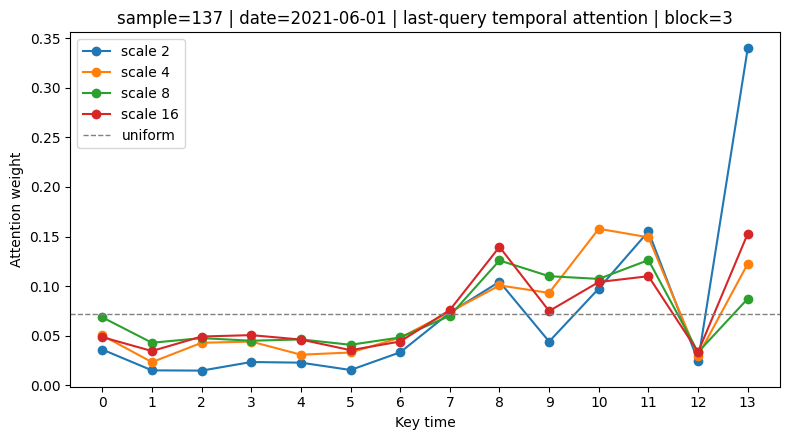

In [14]:
sample_bundle = get_interpret_sample(
    model=model,
    loader=test_loader,
    device=device,
    global_sample_idx=137,
    attn_layers=[-1],
    average_attn_weights=True,
)

print(sample_bundle["meta"])

sample_attn = get_sample_scale_lastquery_attention(sample_bundle)
plot_sample_scale_lastquery_attention(sample_attn)

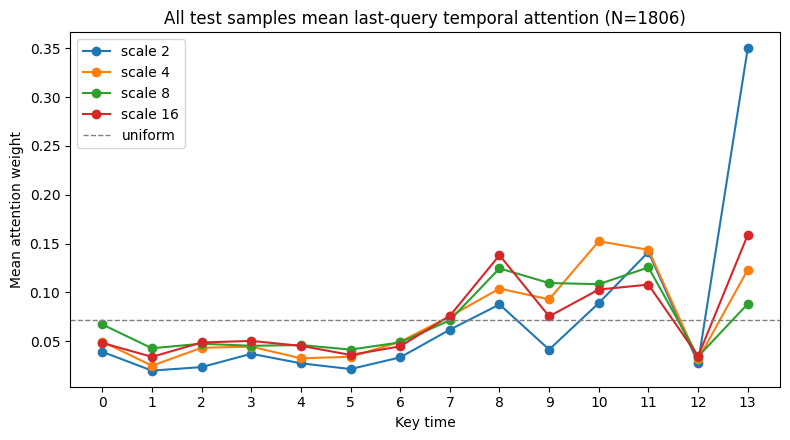

In [15]:
attn_pack_all = collect_temporal_attention_dataset(
    model=model,
    loader=test_loader,
    device=device,
    attn_layers=[-1],
    average_attn_weights=True,
    max_samples=None,
)

summary_all = summarize_dataset_scale_lastquery_attention(attn_pack_all)

plt.figure(figsize=(8, 4.5))
for s in sorted(summary_all["curves"].keys()):
    plt.plot(np.arange(summary_all["T"]), summary_all["curves"][s], marker="o", label=f"scale {s}")

plt.axhline(1.0 / summary_all["T"], linestyle="--", linewidth=1, color="gray", label="uniform")
plt.xticks(np.arange(summary_all["T"]))
plt.xlabel("Key time")
plt.ylabel("Mean attention weight")
plt.title(f"All test samples mean last-query temporal attention (N={summary_all['N']})")
plt.legend()
plt.tight_layout()
plt.show()

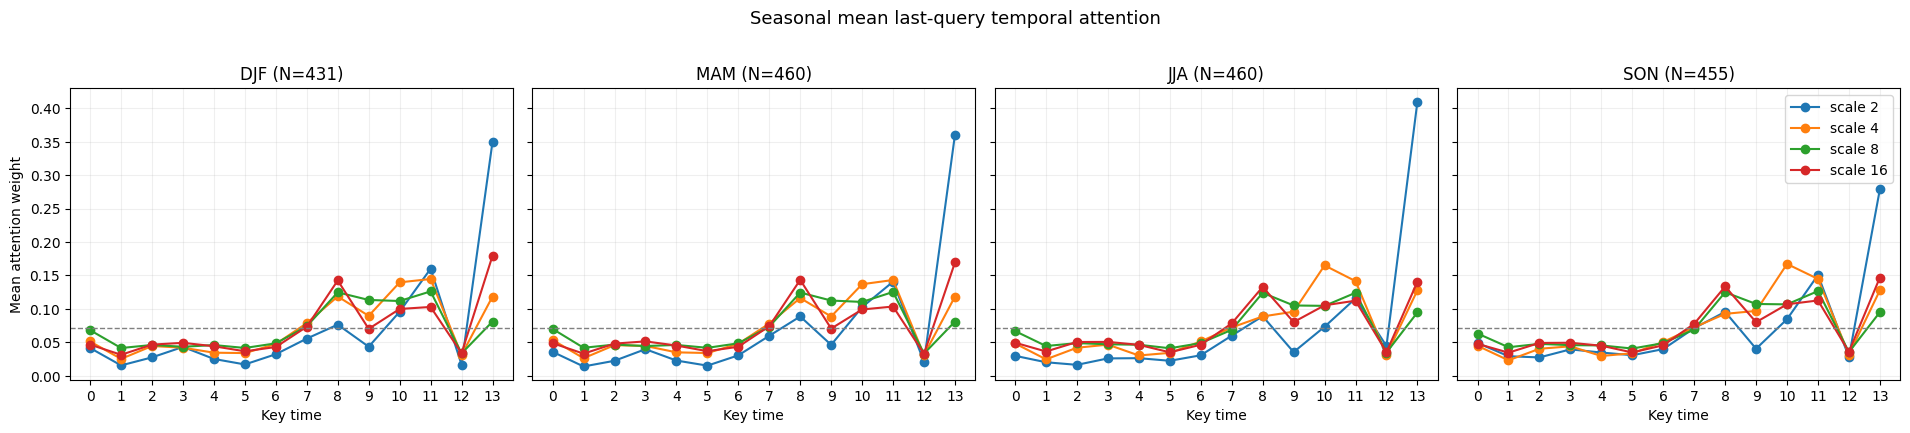

In [16]:
plot_seasonal_scale_lastquery_attention(
    model=model,
    loader=test_loader,
    device=device,
    attn_layers=[-1],
    average_attn_weights=True,
    seasons=("DJF", "MAM", "JJA", "SON"),
    max_samples_per_group=None,
)

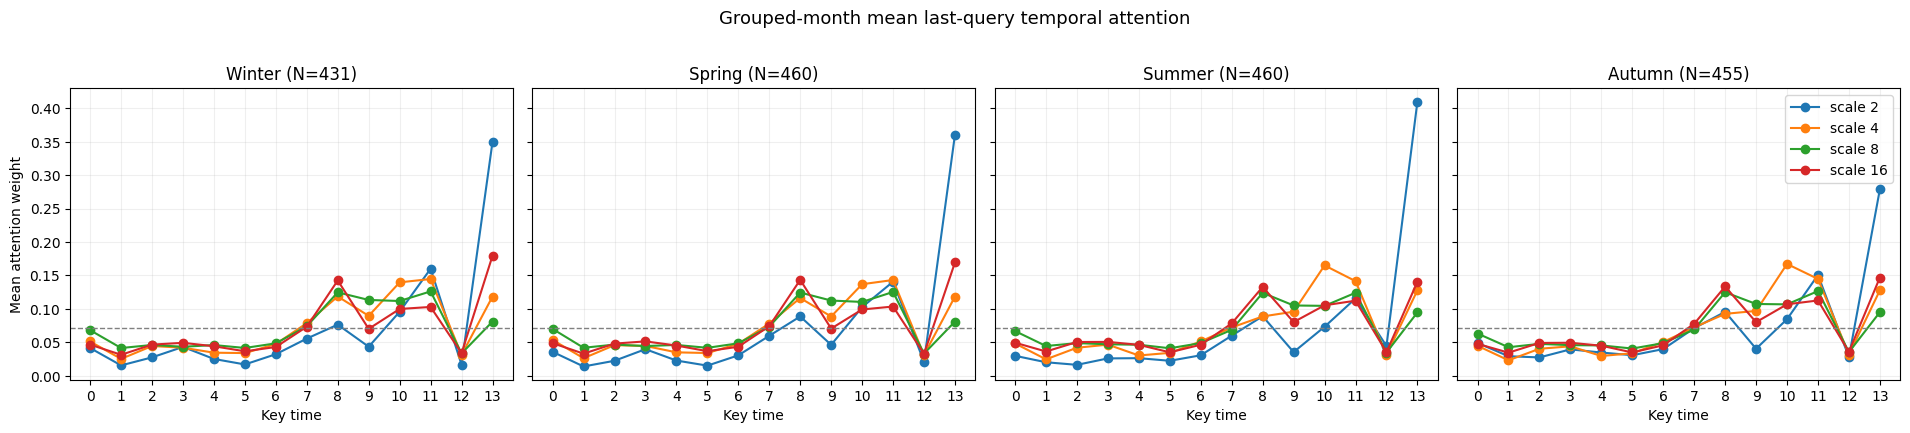

In [17]:
plot_monthly_scale_lastquery_attention(
    model=model,
    loader=test_loader,
    device=device,
    month_groups={
        "Winter": [12, 1, 2],
        "Spring": [3, 4, 5],
        "Summer": [6, 7, 8],
        "Autumn": [9, 10, 11],
    },
    attn_layers=[-1],
    average_attn_weights=True,
    max_samples_per_group=None,
)